# Downloading the data and computing log-returns

In [15]:
# Requirements:
#   pip install yfinance pandas numpy matplotlib statsmodels scipy
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download S&P 500 data
# ----------------------------
ticker = "GLD"
start_date = "2021-01-01"
end_date = "2025-12-31"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


# Time Series Plots

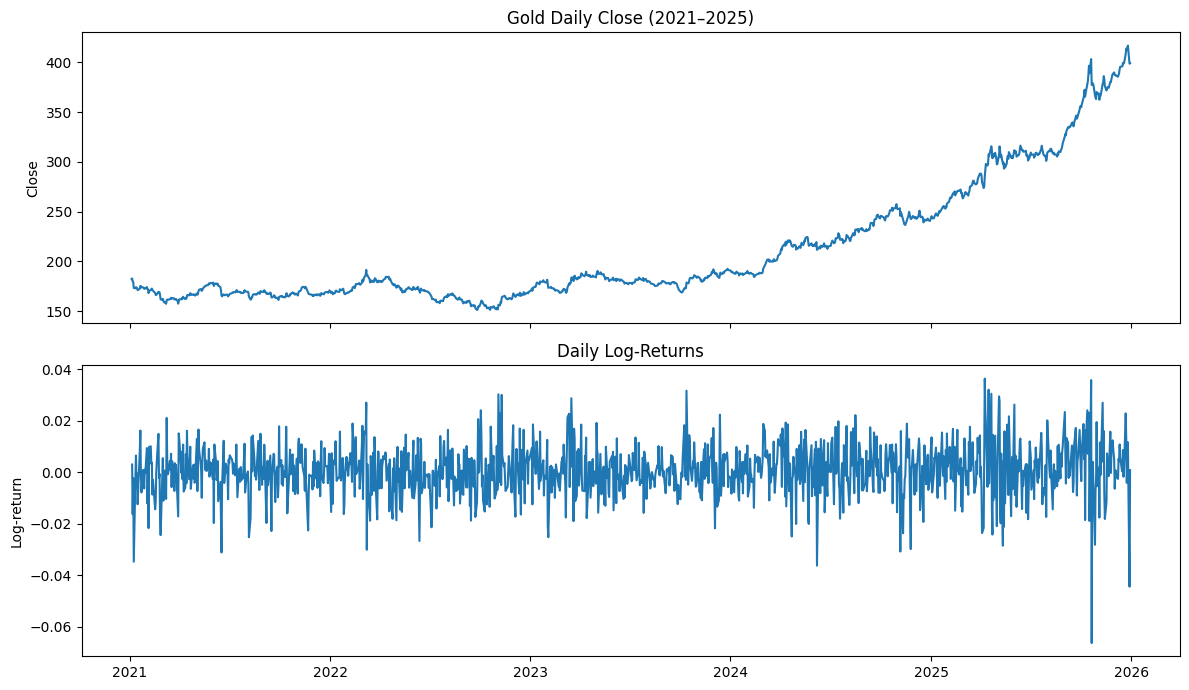

In [16]:

# ----------------------------
# 2x1 plot: prices and log-returns
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(price.index, price)
axes[0].set_title("Gold Daily Close (2021–2025)")
axes[0].set_ylabel("Close")

axes[1].plot(log_ret.index, log_ret)
axes[1].set_title("Daily Log-Returns")
axes[1].set_ylabel("Log-return")


plt.tight_layout()
plt.show()


# Histogram with Normal Distribution



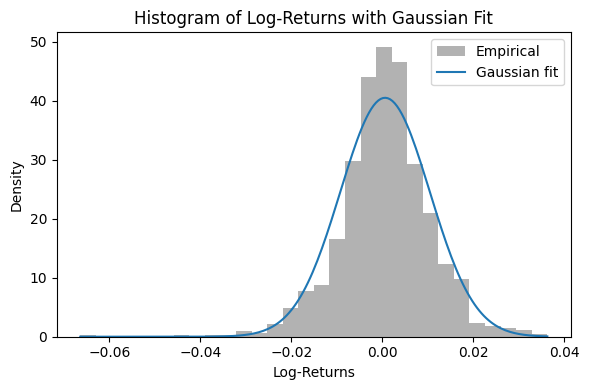

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Estimate Gaussian parameters
mean, std = norm.fit(log_ret)

# Grid for fitted density
x = np.linspace(log_ret.min(), log_ret.max(), 200)
pdf = norm.pdf(x, mean, std)

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(log_ret, bins=30, density=True, alpha=0.6, color='gray', label='Empirical')

# Overlay Gaussian fit
plt.plot(x, pdf, label='Gaussian fit')

plt.title('Histogram of Log-Returns with Gaussian Fit')
plt.xlabel('Log-Returns')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()

plt.show()



# QQ-PLOT WITH NORMAL DISTRIBUTION

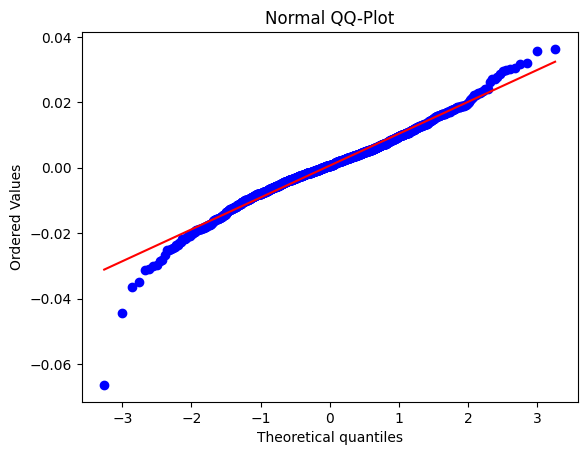

In [5]:
## Here using directly the function probplot
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(log_ret, dist="norm", plot=plt)
plt.title("Normal QQ-Plot")
plt.show()


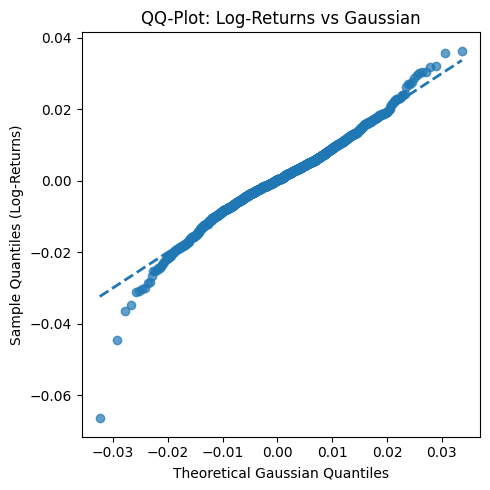

In [6]:
## Here doing it manually if you want further control on the aesthetics
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Drop missing values if any

T = len(log_ret)

# Sort data (sample quantiles)
sample_quantiles = np.sort(log_ret)

# Theoretical Gaussian quantiles
# (use fitted mean and std)
mu, sigma = norm.fit(sample_quantiles)
q = (np.arange(1, T + 1) - 0.5) / T
theoretical_quantiles = norm.ppf(q, loc=mu, scale=sigma)

# QQ-plot
plt.figure(figsize=(5, 5))
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.7)
plt.plot(theoretical_quantiles, theoretical_quantiles, linestyle='--', linewidth=2)

plt.xlabel('Theoretical Gaussian Quantiles')
plt.ylabel('Sample Quantiles (Log-Returns)')
plt.title('QQ-Plot: Log-Returns vs Gaussian')

plt.tight_layout()
plt.show()


# TESTS OF NORMALITY

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.stattools import jarque_bera

results = {}

# Shapiro-Wilk (recommended for small samples)
shapiro_stat, shapiro_p = stats.shapiro(log_ret)
results['Shapiro-Wilk'] = (shapiro_stat, shapiro_p)

# D’Agostino–Pearson K^2 test
dagostino_stat, dagostino_p = stats.normaltest(log_ret)
results['D’Agostino K^2'] = (dagostino_stat, dagostino_p)

# Jarque–Bera test
jb_stat, jb_p, skew, kurtosis = jarque_bera(log_ret)
results['Jarque–Bera'] = (jb_stat, jb_p)

# Kolmogorov–Smirnov test
# IMPORTANT: parameters must be specified
mu, sigma = stats.norm.fit(log_ret)
ks_stat, ks_p = stats.kstest(log_ret, 'norm', args=(mu, sigma))
results['Kolmogorov–Smirnov'] = (ks_stat, ks_p)

# Anderson–Darling test (no p-value, critical values instead)
ad_result = stats.anderson(log_ret, dist='norm')

# Display results
for test, (stat, p) in results.items():
    print(f"{test}: statistic = {stat:.4f}, p-value = {p:.4e}")

print("\nAnderson–Darling test:")
print(f"Statistic: {ad_result.statistic:.4f}")
for cv, sl in zip(ad_result.critical_values, ad_result.significance_level):
    print(f"Critical value at {sl}%: {cv}")


Shapiro-Wilk: statistic = 0.9768, p-value = 2.6745e-13
D’Agostino K^2: statistic = 110.6826, p-value = 9.2381e-25
Jarque–Bera: statistic = 409.5542, p-value = 1.1653e-89
Kolmogorov–Smirnov: statistic = 0.0476, p-value = 6.6103e-03

Anderson–Darling test:
Statistic: 5.0408
Critical value at 15.0%: 0.574
Critical value at 10.0%: 0.654
Critical value at 5.0%: 0.785
Critical value at 2.5%: 0.915
Critical value at 1.0%: 1.089


# Skewness and Kurtosis of the data


In [8]:
from scipy.stats import skew, kurtosis

skewness = skew(log_ret)

# Kurtosis (excess kurtosis, by default subtracts 3)
kurt = kurtosis(log_ret, fisher=True)  # Fisher=True for excess kurtosis

# Adjust kurtosis to include baseline of 3
kurt_with_baseline = kurt + 3

# Print results
print(f"Skewness: {skewness}")
print(f"Kurtosis (Excess): {kurt}")
print(f"Kurtosis (Including Normal Baseline): {kurt_with_baseline}")

Skewness: -0.36333340881436327
Kurtosis (Excess): 2.704915559724517
Kurtosis (Including Normal Baseline): 5.704915559724517
